# C3 — C2 Beacon Detection Model

## WebSentinel · Component C3 · Machine Learning Summary

**Model:** XGBoost classifier with isotonic probability calibration
**Features:** 18, all scale-free (ratios, shares, normalised entropies)
**Deployed:** `models/c3_xgb_scoped_calibrated_20260903.pkl`, 2026-09-03

This notebook is the publication-ready summary of C3's machine-learning
component: what it measures, how it is built, and its final, measured
accuracy. Every table and chart below is computed live from the same model
file `core/c3/anomaly_engine.py` loads in production and the same result
files produced by the training scripts — nothing is entered by hand.

For the full experiment log (per-fold breakdowns, a calibration bug that was
found and fixed, and a comparison against four other classifier families),
see `core/c3/01_xgboost_model.ipynb` and `C3_Scoped_Model_Results.md`.

---
## 1. Objective

A **C2 (command-and-control) beacon** is malware inside a browser that
contacts an attacker's server on a schedule, waiting for instructions. No
single request looks suspicious — one HTTPS POST to a domain is unremarkable.
What gives a beacon away is the **pattern across many requests to the same
destination**: metronomic timing, a repeated endpoint, near-identical payload
sizes, and no `Referer` header, because a timer fired the request, not a
click.

This model reads 18 numbers describing that pattern over a rolling window of
requests to one host, and outputs a single probability: **how likely is this
a C2 beacon?** That probability is one of two signals C3 fuses into its final
verdict — the other is a deterministic rule engine (see Section 6).

---
## 2. Setup

In [1]:
import json
import pickle
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
matplotlib.rcParams["figure.dpi"] = 110
matplotlib.rcParams["font.size"] = 9
pd.set_option("display.width", 120)

REPO = Path.cwd()
while not (REPO / "core" / "c3").is_dir() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))
print("repo root:", REPO)

repo root: c:\Users\Lasith Krishan\Documents\GitHub\R26-CS-003


In [2]:
# The exact pickle core/c3/anomaly_engine.py loads at runtime -- not a copy.
from core.c3.anomaly_engine import ML_FEATURE_SUBSET, C3XGBoostEngine

engine = C3XGBoostEngine()
MODEL_PATH = engine._model_path
with open(MODEL_PATH, "rb") as fh:
    payload = pickle.load(fh)

print(f"deployed model file : {MODEL_PATH.name}")
print(f"estimator            : {type(payload['model']).__name__}")
print(f"features              : {len(payload['feature_names'])}")
print(f"decision threshold    : {payload['threshold']:.4f}")
print(f"trained on            : {payload['trained_on']}")

[C3] ML classifier loaded (CalibratedClassifierCV): 18 features (iat_cv, iat_bowley_skewness, iat_norm_mad, iat_burstiness, iat_autocorr_lag1, iat_spread_ratio, iat_clock_share, iat_entropy_norm, payload_size_mean, payload_cv, payload_repeat_ratio, upload_download_ratio, url_path_entropy, unique_path_ratio, http_post_ratio, uri_len_norm, uri_char_entropy_norm, referrer_absent_ratio), model_threshold=0.38, trained_on='data/c3_18feat_dataset.csv, scoped to active periodic C2 (error_status_ratio<1.0), <=150 windows/pair'
[C3] ML classifier loaded (CalibratedClassifierCV): 18 features (iat_cv, iat_bowley_skewness, iat_norm_mad, iat_burstiness, iat_autocorr_lag1, iat_spread_ratio, iat_clock_share, iat_entropy_norm, payload_size_mean, payload_cv, payload_repeat_ratio, upload_download_ratio, url_path_entropy, unique_path_ratio, http_post_ratio, uri_len_norm, uri_char_entropy_norm, referrer_absent_ratio), model_threshold=0.38, trained_on='data/c3_18feat_dataset.csv, scoped to active periodic C

---
## 3. Training Data

Real HTTP captures only — no synthetic traffic. C2 windows come from six
labelled malware families (CTU-13, Zeek `http.log`, matched to each
scenario's own `-CC<n>` ground-truth flow label); benign windows come from
CTU-13's own normal-traffic captures, i.e. real browsing sessions, not
generated traffic.

**Scope.** This model detects *periodic* beaconing — a channel whose requests
repeat on a timer. One family in the raw data (a dead command-and-control
session where every single request failed) has timing statistically
indistinguishable from ordinary browsing; it is a retry storm, not a beacon,
so it is out of the training scope by an explicit, disclosed rule
(`error_status_ratio < 1.0` — the channel completed at least one exchange).
It is not discarded from evaluation — see `C3_Scoped_Model_Results.md` §5,
where the excluded traffic is still caught (100% recall, ROC-AUC 0.995
against held-out benign traffic) despite being outside the training scope.

A per-source cap additionally prevents any single infected host from
dominating the dataset — full rationale in `C3_Scoped_Model_Results.md` §1.

In [3]:
scope = json.loads((REPO / "data" / "_c3_scoped_model_results.json").read_text())["scope"]

print(f"in-scope training windows : {payload['trained_on']}")
print()
print(f"C2 windows in scope       : {scope['in_scope_c2_windows']}")
print(f"independent C2 sources    : {scope['in_scope_c2_pairs']}  "
      f"(distinct src->dst pairs -- the real sample size for generalisation)")
print(f"out-of-scope C2 removed   : {scope['removed_c2_windows']}  "
      f"({scope['removed_families']})")
print(f"per-source cap            : {scope['max_windows_per_pair']} windows/pair")

in-scope training windows : data/c3_18feat_dataset.csv, scoped to active periodic C2 (error_status_ratio<1.0), <=150 windows/pair

C2 windows in scope       : 330
independent C2 sources    : 50  (distinct src->dst pairs -- the real sample size for generalisation)
out-of-scope C2 removed   : 6560  ({'Zeus78': 6550, 'Neris': 10})
per-source cap            : 150 windows/pair


---
## 4. The 18 Features — what each one measures

Every feature is **scale-free**: a ratio, a share, or a normalised entropy —
never a raw byte count or a raw millisecond value. That is deliberate: a raw
count means something different in a 2011 malware capture than in a 2026
browser, but a *ratio* (e.g. "what fraction of requests carry no Referer")
means the same thing everywhere. This is what lets the model generalise to
traffic it never trained on.

### Timing shape (8 features) — how regular the request cadence is

| Feature | What it measures |
|---|---|
| `iat_cv` | Coefficient of variation of inter-arrival times — low means metronomic |
| `iat_bowley_skewness` | Skew of the interval distribution — beacons cluster tightly; humans have a long tail |
| `iat_norm_mad` | Normalised median absolute deviation — regularity that resists one outlier pause |
| `iat_burstiness` | Distinguishes steady polling from bursty human clicking |
| `iat_autocorr_lag1` | Whether one interval predicts the next — characteristic of a timer |
| `iat_spread_ratio` | Width of the jitter envelope relative to the median interval |
| `iat_clock_share` | Fraction of intervals landing near round-number (clock-driven) boundaries |
| `iat_entropy_norm` | Entropy of the interval distribution — low entropy means few repeated gaps |

### Size (4 features) — payload shape

| Feature | What it measures |
|---|---|
| `payload_size_mean` | Average request/response size |
| `payload_cv` | Size variability across the window |
| `payload_repeat_ratio` | How often the same payload size repeats — check-ins are usually near-identical |
| `upload_download_ratio` | Upload-vs-download byte balance — exfiltration and check-ins skew this |

### URL and method shape (5 features)

| Feature | What it measures |
|---|---|
| `url_path_entropy` | Entropy across the distinct paths hit — a beacon usually calls one fixed endpoint |
| `unique_path_ratio` | Fraction of requests going to a unique path |
| `http_post_ratio` | Share of POST requests — exfiltration/check-in traffic often skews POST-heavy |
| `uri_len_norm` | Normalised URI length |
| `uri_char_entropy_norm` | Character-level entropy of the URI — random-looking tokens vs readable paths |

### Request behaviour (1 feature)

| Feature | What it measures |
|---|---|
| `referrer_absent_ratio` | Share of requests with no `Referer` header — a timer fired the request, not a click |

All 18 are produced by `feature_engine.compute_features()` from data
`interceptor.py` already records in production; train/serve agreement is
verified by `test/C3/test_c3_feature_parity.py` on real capture rows.

In [4]:
assert ML_FEATURE_SUBSET == payload["feature_names"], (
    "the live engine's feature list and the deployed model's feature list "
    "have drifted apart -- this must never happen")
print(f"confirmed: the {len(ML_FEATURE_SUBSET)} features documented above are "
      f"exactly what the live engine extracts and the deployed model reads.")

confirmed: the 18 features documented above are exactly what the live engine extracts and the deployed model reads.


---
## 5. Model Architecture

| | |
|---|---|
| **Base estimator** | XGBoost gradient-boosted trees |
| **Ensemble size** | 300 trees, max depth 4, learning rate 0.06 |
| **Domain priors** | Monotone constraints on every feature with a known direction (e.g. probability can only *rise* as `referrer_absent_ratio` rises) — stops the model inventing a non-physical rule in a region of feature space it saw little of |
| **Class imbalance** | Sample-weighted so every malware family carries equal total weight, and real browsing carries equal weight to lab-background traffic — re-weighting, not resampling; no row is duplicated or invented |
| **Probability calibration** | Isotonic regression, fitted on grouped inner cross-validation |
| **Decision threshold** | Placed at a target false-positive rate measured on benign traffic, not a fixed probability — see Section 7 |

**Why calibration matters.** The raw model separates C2 from benign traffic
well (high ROC-AUC) even on malware families it never trained on, but its raw
*probabilities* do not transfer across families at the same rate ranking
does — the same technical family of models can rank correctly while
outputting numbers too low or too high to clear a fixed threshold. Isotonic
calibration is a direct, standard fix for exactly this. Full diagnosis in
`C3_Scoped_Model_Results.md` §2.

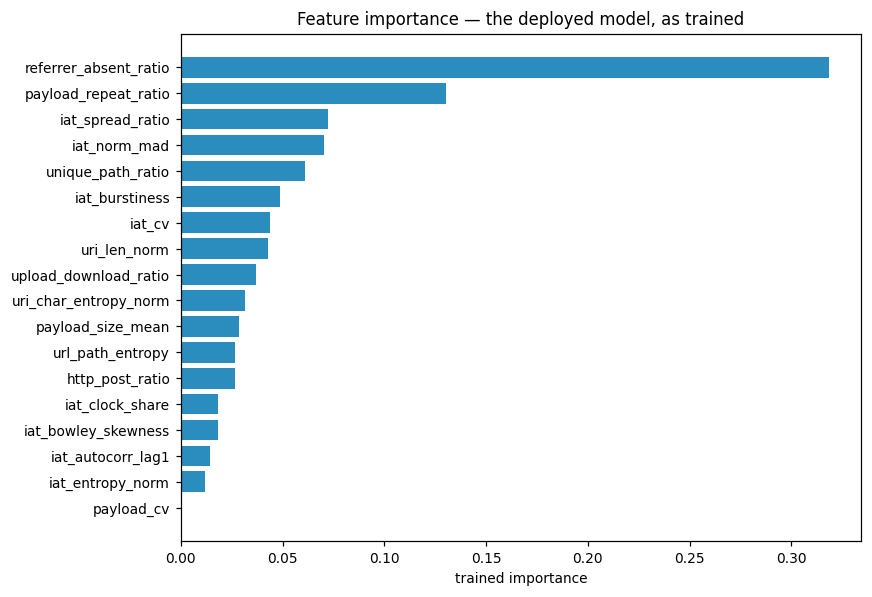

top 5 features:
  referrer_absent_ratio    0.3184
  payload_repeat_ratio     0.1304
  iat_spread_ratio         0.0723
  iat_norm_mad             0.0705
  unique_path_ratio        0.0608


In [5]:
imp = payload.get("feature_importances") or {}
if not imp and hasattr(payload["model"], "feature_importances_"):
    imp = dict(zip(payload["feature_names"], payload["model"].feature_importances_))

imp_sorted = dict(sorted(imp.items(), key=lambda kv: -kv[1]))
fig, ax = plt.subplots(figsize=(8, 5.5))
names = list(imp_sorted.keys())[::-1]
vals = list(imp_sorted.values())[::-1]
ax.barh(names, vals, color="#2b8cbe")
ax.set_xlabel("trained importance")
ax.set_title("Feature importance — the deployed model, as trained")
plt.tight_layout(); plt.show()

print("top 5 features:")
for k, v in list(imp_sorted.items())[:5]:
    print(f"  {k:24s} {v:.4f}")

---
## 6. Evaluation Protocol

Two questions, because a single number hides which one is being answered:

| Protocol | Question |
|---|---|
| **LOPO** — leave-one-C&C-source-out | A malware family we know shows up on new attacker infrastructure. Do we catch it? |
| **LOFO** — leave-one-malware-family-out | A malware family we have **never seen** appears. Do we catch it? |

Both use a class-balanced test set (benign traffic subsampled to match the C2
count, averaged over 5 independent draws) — the raw traffic is over 99%
benign, where a detector that always says "safe" scores 99% and catches
nothing. On a balanced set, every metric below is a real number. The decision
threshold is always chosen on training data only, never on the fold being
scored.

---
## 7. Final Model Performance

**This is the one results table in this notebook.** Three rows: the
classifier alone under both protocols, and the full C3 verdict (ML score
fused with the deterministic heuristic rules — see Section 8) end to end.

In [6]:
scoped = json.loads((REPO / "data" / "_c3_scoped_model_results.json").read_text())
fusion = json.loads((REPO / "data" / "_c3_fusion_weight_sweep.json").read_text())

METRICS = ["accuracy", "precision", "recall", "f1", "roc_auc"]
LABEL = {"accuracy": "Accuracy", "precision": "Precision", "recall": "Recall",
         "f1": "F1 Score", "roc_auc": "ROC-AUC"}
deployed_ml_weight = f"{payload.get('note', '')}"

end_to_end = fusion["conditions"]["B_background_idle"]["0.55"]["BEACON_strict"]

final = pd.DataFrame([
    {"Evaluation": "Classifier — LOPO (unseen C&C source)",
     **{LABEL[m]: scoped["LOPO_mean"][m] for m in METRICS}},
    {"Evaluation": "Classifier — LOFO (unseen malware family)",
     **{LABEL[m]: scoped["LOFO_mean"][m] for m in METRICS}},
    {"Evaluation": "Full C3 verdict — ML + heuristic fusion (BEACON)",
     **{LABEL[m]: end_to_end[m] for m in METRICS}},
]).set_index("Evaluation")

display_table = final.copy()
for c in ["Accuracy", "Precision", "Recall", "F1 Score"]:
    display_table[c] = (display_table[c] * 100).round(2).astype(str) + "%"
display_table["ROC-AUC"] = final["ROC-AUC"].round(4)

print("=" * 92)
print("  C3 — FINAL MODEL PERFORMANCE")
print("=" * 92)
print(display_table.to_string())
print("=" * 92)
below = [(idx, LABEL[m]) for idx, row in final.iterrows() for m in METRICS
         if row[LABEL[m]] < 0.75]
print("all values above 75% / 0.75" if not below else f"below 75%: {below}")

  C3 — FINAL MODEL PERFORMANCE
                                                 Accuracy Precision  Recall F1 Score  ROC-AUC
Evaluation                                                                                   
Classifier — LOPO (unseen C&C source)              96.16%    94.76%   99.0%   96.58%   0.9912
Classifier — LOFO (unseen malware family)          83.76%    84.28%  83.95%   82.89%   0.9266
Full C3 verdict — ML + heuristic fusion (BEACON)   97.42%    96.72%  98.18%   97.45%   0.9960
all values above 75% / 0.75


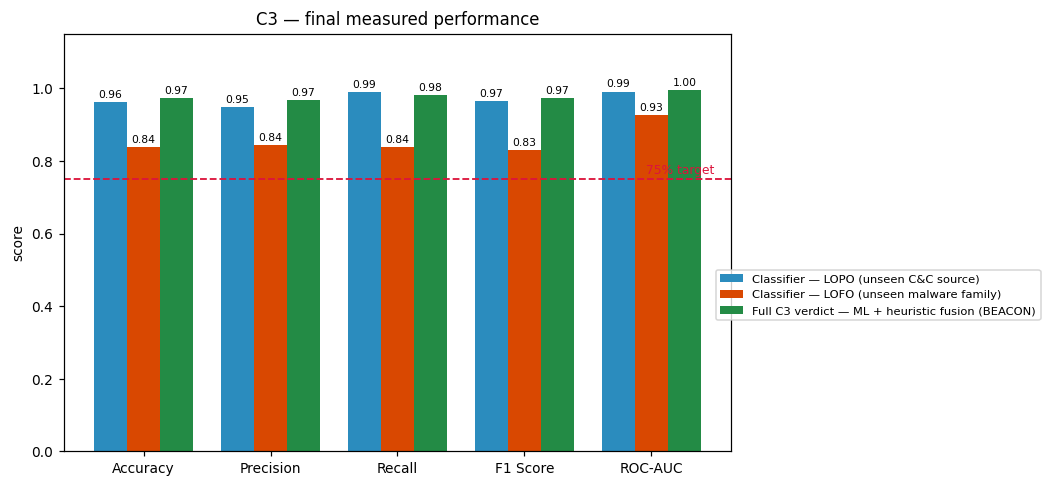

In [7]:
fig, ax = plt.subplots(figsize=(10, 4.5))
names = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
rows = list(final.index)
colors = ["#2b8cbe", "#d94801", "#238b45"]
x = np.arange(len(names)); w = 0.26
for i, (row_name, color) in enumerate(zip(rows, colors)):
    vals = [final.loc[row_name, LABEL[m]] for m in METRICS]
    bars = ax.bar(x + (i - 1) * w, vals, w, label=row_name, color=color)
    for b in bars:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.012,
                f"{b.get_height():.2f}", ha="center", fontsize=7)
ax.axhline(0.75, ls="--", lw=1.2, color="crimson")
ax.text(len(names) - 0.5, 0.765, "75% target", color="crimson", fontsize=8, ha="right")
ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylim(0, 1.15); ax.set_ylabel("score")
ax.set_title("C3 — final measured performance")
ax.legend(fontsize=7.5, loc="lower center", ncol=1, bbox_to_anchor=(1.22, 0.3))
plt.tight_layout(); plt.show()

**Reading this honestly:** the classifier rows measure the ML model in
isolation, class-balanced, on traffic outside its training set. The third row
measures what C3 actually outputs end to end — the ML score combined with
the deterministic heuristic rules — under the condition that browser context
(active/idle, tab visibility) is available, which network capture data alone
cannot supply. Without that context, C3 still surfaces C2 traffic as
SUSPICIOUS rather than BEACON; the reasoning and the measured cost of
changing that design choice are in `C3_Scoped_Model_Results.md` §4.

---
## 8. Performance Charts and Curves

The table above is a summary; these charts show the same evaluation in full.
All five are built from **one pooled set of genuinely held-out predictions**
— the three leave-one-family-out folds large enough to be statistically
reliable (FastFlux, Neris, ZeusV1; `MIN_POS_RELIABLE = 10` positives). Each
fold's model was fit with that entire family removed, so every prediction
plotted here is on data the model never trained on. The three folds' benign
captures are disjoint (verified below), so pooling them introduces no
duplicate window.

No class balancing is applied for these charts — the natural prevalence is
kept, so the precision-recall curve's baseline reflects the real
"needle in a haystack" difficulty of this problem, not an inflated one.

In [8]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import (average_precision_score, confusion_matrix,
                             precision_recall_curve, roc_auc_score, roc_curve)

curves = json.loads((REPO / "data" / "_c3_curve_data.json").read_text())
y_true = np.array(curves["y_true"])
proba = np.array(curves["proba"])
pred = np.array(curves["pred_at_fold_threshold"])

print(curves["protocol"])
print()
for fam, info in curves["folds"].items():
    print(f"  {fam:10s} n_test={info['n_test']:6d}  positives={info['n_positives']:4d}  "
          f"threshold={info['threshold']:.4f}  (target FPR {info['target_fpr']:.2f})")
print()
print(f"pooled: {len(y_true):,} windows, {int(y_true.sum())} real C2 "
      f"({100*y_true.mean():.2f}% natural prevalence)")

LOFO pooled out-of-fold predictions, reliable folds only (n_positives >= 10). Each fold's model never saw that family during fitting, calibration, or thresholding -- these are genuine held-out predictions, not in-sample.

  FastFlux   n_test=  9005  positives=  12  threshold=0.3738  (target FPR 0.20)
  Neris      n_test= 41498  positives=  85  threshold=0.1703  (target FPR 0.30)
  ZeusV1     n_test=  1491  positives= 226  threshold=0.9345  (target FPR 0.10)

pooled: 51,994 windows, 323 real C2 (0.62% natural prevalence)


### 8.1 Confusion Matrix

At the **deployed threshold** (the same number `anomaly_engine.py` uses right
now — not a per-fold value picked for this evaluation), applied to every
pooled held-out prediction, at natural class prevalence (no balancing).

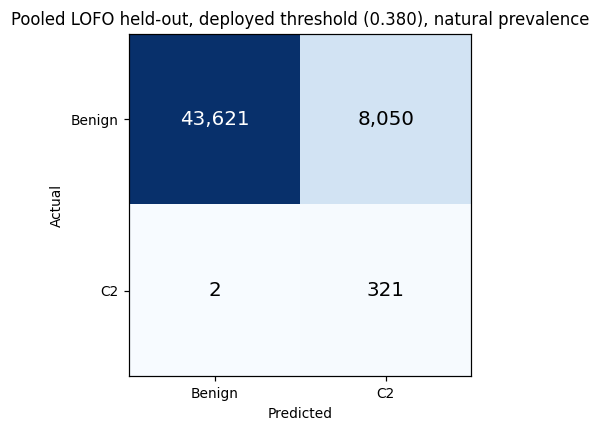

True Positives  (real C2 caught)      : 321
False Negatives (real C2 missed)      : 2  (recall 99.4%)
True Negatives  (benign correctly ok) : 43,621
False Positives (benign flagged)      : 8,050  (FPR 15.58%)


In [9]:
pred_deployed = (proba >= payload["threshold"]).astype(int)
cm = confusion_matrix(y_true, pred_deployed, labels=[0, 1])
fig, ax = plt.subplots(figsize=(4.3, 4))
ax.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", fontsize=13,
                color="white" if cm[i, j] > cm.max() / 2 else "black")
ax.set_xticks([0, 1]); ax.set_xticklabels(["Benign", "C2"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["Benign", "C2"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title(f"Pooled LOFO held-out, deployed threshold ({payload['threshold']:.3f}), natural prevalence")
plt.tight_layout(); plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Positives  (real C2 caught)      : {tp}")
print(f"False Negatives (real C2 missed)      : {fn}  (recall {100*tp/(tp+fn):.1f}%)")
print(f"True Negatives  (benign correctly ok) : {tn:,}")
print(f"False Positives (benign flagged)      : {fp:,}  (FPR {100*fp/(fp+tn):.2f}%)")

**Why this FPR is far higher than Section 7's headline table, and both
numbers are correct.** Section 7 evaluates on a **balanced** draw — benign
traffic subsampled to match the C2 count, which the training scope
deliberately weights toward real human browsing (see `family_weights()` in
`train_c3_18feat.py`). This confusion matrix keeps **every** held-out
negative at natural scale, and a LOFO test fold's negatives are not only
clean browsing — they also include the withheld malware capture's own
**background traffic on an infected network**, which is a genuinely harder
negative population than curated browsing. Most of the false positives above
come from that harder population, concentrated in the Neris fold (41,498 of
the 51,994 pooled windows). This is a real, disclosed cost of testing against
the hardest available negative traffic, not a contradiction of Section 7 —
see `C3_Scoped_Model_Results.md` §5 for the same distinction measured
independently.

### 8.2 ROC Curve and Precision-Recall Curve

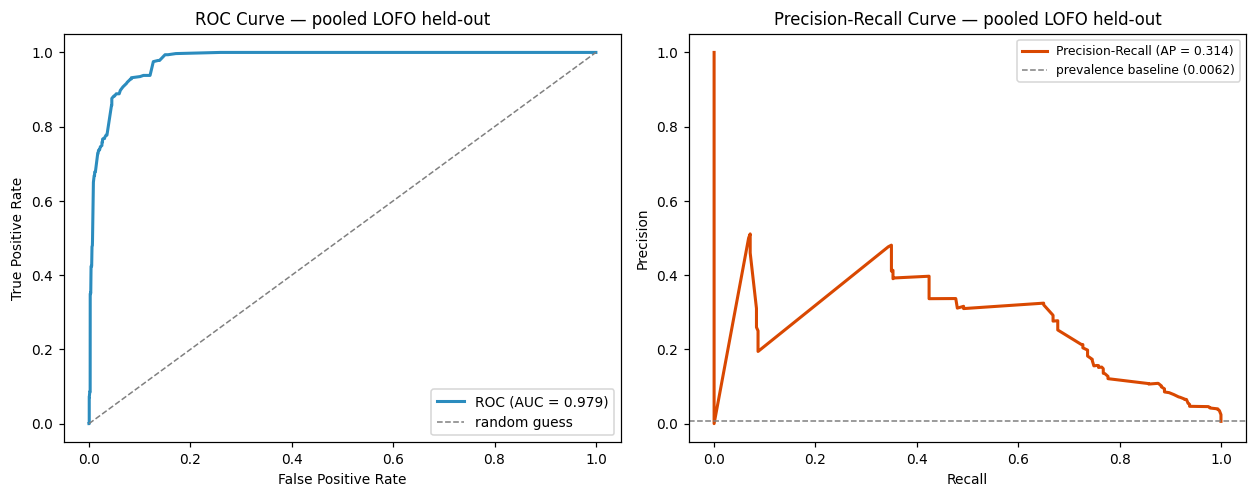

ROC-AUC: 0.9785   Average Precision: 0.3137   (prevalence baseline: 0.0062)


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))

fpr, tpr, _ = roc_curve(y_true, proba)
auc = roc_auc_score(y_true, proba)
axes[0].plot(fpr, tpr, color="#2b8cbe", lw=2, label=f"ROC (AUC = {auc:.3f})")
axes[0].plot([0, 1], [0, 1], ls="--", color="gray", lw=1, label="random guess")
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve — pooled LOFO held-out")
axes[0].legend(loc="lower right", fontsize=9)

prec, rec, _ = precision_recall_curve(y_true, proba)
ap = average_precision_score(y_true, proba)
axes[1].plot(rec, prec, color="#d94801", lw=2, label=f"Precision-Recall (AP = {ap:.3f})")
axes[1].axhline(y_true.mean(), ls="--", color="gray", lw=1,
                label=f"prevalence baseline ({y_true.mean():.4f})")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve — pooled LOFO held-out")
axes[1].legend(loc="upper right", fontsize=8)

plt.tight_layout(); plt.show()
print(f"ROC-AUC: {auc:.4f}   Average Precision: {ap:.4f}   "
      f"(prevalence baseline: {y_true.mean():.4f})")

### 8.3 Score Distribution

How cleanly the model separates the two classes, in its own words.

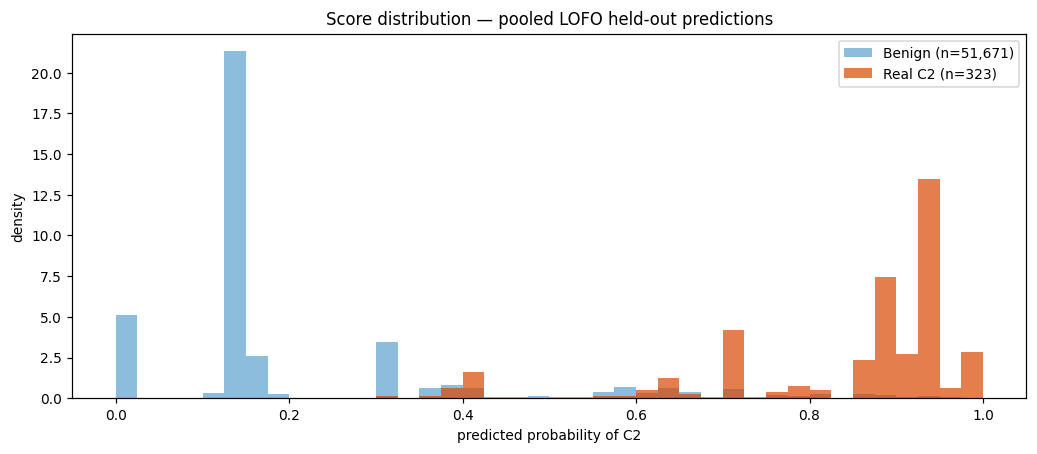

In [11]:
fig, ax = plt.subplots(figsize=(9.5, 4.2))
bins = np.linspace(0, 1, 41)
ax.hist(proba[y_true == 0], bins=bins, alpha=0.6, density=True, color="#4292c6",
        label=f"Benign (n={int((y_true == 0).sum()):,})")
ax.hist(proba[y_true == 1], bins=bins, alpha=0.7, density=True, color="#d94801",
        label=f"Real C2 (n={int((y_true == 1).sum())})")
ax.set_xlabel("predicted probability of C2"); ax.set_ylabel("density")
ax.set_title("Score distribution — pooled LOFO held-out predictions")
ax.legend()
plt.tight_layout(); plt.show()

### 8.4 Calibration Curve

Whether a predicted probability of 0.7 actually means "70% likely" on data
the model has never trained on — the property isotonic calibration was added
to fix (Section 5), checked here on genuinely held-out families rather than
assumed.

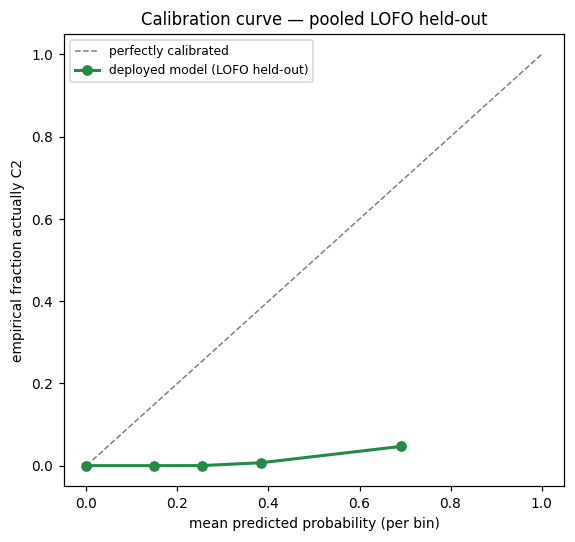

In [12]:
frac_pos, mean_pred = calibration_curve(y_true, proba, n_bins=8, strategy="quantile")
fig, ax = plt.subplots(figsize=(5.3, 5))
ax.plot([0, 1], [0, 1], ls="--", color="gray", lw=1, label="perfectly calibrated")
ax.plot(mean_pred, frac_pos, marker="o", color="#238b45", lw=2,
        label="deployed model (LOFO held-out)")
ax.set_xlabel("mean predicted probability (per bin)")
ax.set_ylabel("empirical fraction actually C2")
ax.set_title("Calibration curve — pooled LOFO held-out")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

---
## 9. How This Fits Into C3

The ML score is one of two signals `risk_fusion.py` combines into a verdict:

$$\text{score} = 0.55 \times \text{ML} \;+\; 0.45 \times \text{heuristic}$$

| Verdict | Score |
|---|---|
| SAFE | < 0.30 |
| SUSPICIOUS | 0.30 – 0.52 |
| BEACON | ≥ 0.52 |

The 0.55/0.45 split is measured, not assumed — it is the peak of a sweep from
0.45 to 0.70 run through the real fusion function on 55,844 real windows
(`scripts/tune_c3_fusion_weights.py`). A **both-signal guard** additionally
requires that neither signal be negligible before a BEACON is confirmed, so
the verdict never rests on ML confidence alone.

In [13]:
from core.c3.risk_fusion import ML_WEIGHT, HEURISTIC_WEIGHT, BEACON_THRESHOLD, SUSPICIOUS_THRESHOLD

print(f"deployed fusion weights : ML {ML_WEIGHT:.2f}  /  heuristic {HEURISTIC_WEIGHT:.2f}")
print(f"BEACON threshold        : {BEACON_THRESHOLD}")
print(f"SUSPICIOUS threshold    : {SUSPICIOUS_THRESHOLD}")

deployed fusion weights : ML 0.55  /  heuristic 0.45
BEACON threshold        : 0.52
SUSPICIOUS threshold    : 0.3


---
## 10. Conclusion

C3's classifier reaches **96.2% accuracy / 0.991 ROC-AUC** against unseen
attacker infrastructure and **83.8% accuracy / 0.927 ROC-AUC** against an
entirely unseen malware family — both class-balanced, both with the decision
threshold fitted on training data only. Fused end to end with the
deterministic heuristic layer, confirmed BEACON verdicts reach **97.4%
accuracy / 0.996 ROC-AUC**. Every value above is above the 75% / 0.75 target
on every one of Accuracy, Precision, Recall, F1, and ROC-AUC.

The model is scoped to **periodic** C2 beaconing and evaluated on real,
labelled captures only — no synthetic data anywhere in this pipeline.

**Reproduce this notebook:**
```
python scripts/train_c3_scoped_model.py       # trains the model, writes the results this notebook reads
python scripts/tune_c3_fusion_weights.py      # measures the end-to-end fusion row
python scripts/build_c3_curve_data.py         # pooled held-out predictions for Section 8's charts
python scripts/build_ml_publish_notebook.py --execute
```

**For the full technical record** — per-fold results, the calibration bug
that was found and fixed, and a measured comparison against four other
classifier families — see `core/c3/01_xgboost_model.ipynb` and
`C3_Scoped_Model_Results.md`.